<a href="https://colab.research.google.com/github/agmelendez/SP-8502_GIACTUCR/blob/claude%2Fstudent-folder-structure-DqxtH/webscraping_news.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import feedparser
import requests
from newspaper import Article, Config
from textblob import TextBlob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def get_news_urls(keywords):
    """
    Fetches one news URL per keyword using Google News RSS.
    """
    urls_map = {}
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    print(f"--- Searching for news on {len(keywords)} keywords ---")

    for keyword in keywords:
        # Use Google News RSS to avoid anti-scraping blocks
        rss_url = f"https://news.google.com/rss/search?q={keyword}&hl=en-US&gl=US&ceid=US:en"
        feed = feedparser.parse(rss_url)

        if feed.entries:
            # Get the link of the first (most relevant) news item
            # Google RSS links often need to be resolved to get the real news site URL
            try:
                redirect_url = feed.entries[0].link
                urls_map[keyword] = redirect_url
                print(f"[FOUND] {keyword}: {feed.entries[0].title}")
            except Exception as e:
                print(f"[ERROR] Could not retrieve link for {keyword}")
        else:
            print(f"[MISSING] No news found for {keyword}")

    return urls_map

def scrape_and_analyze(urls_map):
    """
    Scrapes the text from the URLs and calculates sentiment polarity.
    Polarity ranges from -1 (Very Negative) to +1 (Very Positive).
    """
    results = []
    total_sentiment = 0
    count = 0

    # Configuration to mimick a real browser
    config = Config()
    config.browser_user_agent = 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'
    config.request_timeout = 10

    print("\n--- Scraping and Analyzing Pages ---")

    for keyword, url in urls_map.items():
        try:
            article = Article(url, config=config)
            article.download()
            article.parse()

            # Get text and perform analysis
            text = article.text
            blob = TextBlob(text)
            sentiment_score = blob.sentiment.polarity

            results.append({
                "keyword": keyword,
                "title": article.title,
                "score": sentiment_score
            })

            total_sentiment += sentiment_score
            count += 1
            print(f"[ANALYZED] {keyword} (Score: {sentiment_score:.2f})")

        except Exception as e:
            print(f"[FAILED] Could not scrape {keyword}. Error: {e}")

    avg_sentiment = total_sentiment / count if count > 0 else 0
    return results, avg_sentiment

def create_thermometer(avg_score):
    """
    Creates a visual 'thermometer' based on the average sentiment score.
    Range: -1.0 (Negative/Red) to 1.0 (Positive/Green)
    """
    print(f"\n--- Generating Sentiment Thermometer (Average Score: {avg_score:.4f}) ---")

    fig, ax = plt.subplots(figsize=(10, 3))

    # Define the color gradient (Red to Yellow to Green)
    cmap = mcolors.LinearSegmentedColormap.from_list("", ["red", "yellow", "green"])

    # Create the background bar (the range -1 to 1)
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    gradient = np.vstack((gradient, gradient))

    # Display the gradient
    ax.imshow(gradient, aspect='auto', cmap=cmap, extent=[-1, 1, 0, 1])

    # Remove Y axis and frame
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    # Add the indicator needle/line
    plt.axvline(x=avg_score, color='black', linestyle='--', linewidth=4, label='Current Sentiment')

    # Add text label for the score
    plt.text(avg_score, 1.1, f"{avg_score:.2f}", horizontalalignment='center', fontsize=12, fontweight='bold')

    # Labels
    ax.set_title(f'News Sentiment Thermometer', fontsize=14)
    ax.set_xlabel('Negative (-1.0) <------ Neutral (0.0) ------> Positive (+1.0)')

    # Adjust layout
    plt.tight_layout()
    plt.show()

def main():
    # 1. Define your 10 keywords
    keywords = [
        "Artificial Intelligence",
        "Climate Change",
        "Stock Market",
        "Cryptocurrency",
        "Space Exploration",
        "Electric Vehicles",
        "Cybersecurity",
        "Remote Work",
        "Healthcare Innovation",
        "Global Supply Chain"
    ]

    # 2. Get URLs
    urls_map = get_news_urls(keywords)

    # 3. Scrape and Analyze
    if urls_map:
        article_data, average_score = scrape_and_analyze(urls_map)

        # Print Summary
        print("\n--- Summary Report ---")
        for item in article_data:
            sentiment_word = "Neutral"
            if item['score'] > 0.1: sentiment_word = "Positive"
            elif item['score'] < -0.1: sentiment_word = "Negative"

            print(f"Keyword: {item['keyword']:<20} | Score: {item['score']:>6.2f} | {sentiment_word}")

        # 4. Create Thermometer
        create_thermometer(average_score)
    else:
        print("No URLs found to analyze.")

if __name__ == "__main__":
    main()

ImportError: lxml.html.clean module is now a separate project lxml_html_clean.
Install lxml[html_clean] or lxml_html_clean directly.

In [ ]:
pip install feedparser newspaper3k textblob matplotlib numpy

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 83.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 6.1 MB/s eta 0:00:00
  Created wheel for tinysegmenter: filename=tinysegmenter-0.3-py3-none-any.whl size=13540 sha256=a4ff71153ec6391d10560f670be38d66c293855bf79f9f7012d3560d57c145e8
  Stored in directory: /root/.cache/pip/wheels/a5/91/9f/00d66475960891a64867914273fcaf78df6cb04d905b104a2a
  Created wheel for feedfinder2: filename=feedfinder2-0.0.4-py3-none-any.whl size=3341 sha256=d1b0aea6bba0c5a5dbc9515f88b163e5ca50bb9e9a0f7e15ef333e8038462872
  Stored in directory: /root/.cache/pip/wheels/9f/9f/fb/364871d7426d3cdd4d293dcf7e53d97f16

In [ ]:
import feedparser
import requests
from newspaper import Article, Config
from textblob import TextBlob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from deep_translator import GoogleTranslator

# Initialize translator
translator = GoogleTranslator(source='auto', target='en')
to_spanish = GoogleTranslator(source='auto', target='es')

def get_news_urls_cr(keywords):
    """
    Fetches news from Costa Rica (gl=CR) in Spanish (ceid=CR:es).
    Automatically translates English keywords to Spanish for better local results.
    """
    urls_map = {}

    print(f"--- Searching for Costa Rican news on {len(keywords)} keywords ---")

    for keyword in keywords:
        try:
            # 1. Translate keyword to Spanish for better local search results
            keyword_es = to_spanish.translate(keyword)

            # 2. Construct Google News RSS URL for Costa Rica
            # gl=CR (Geo Location: Costa Rica)
            # ceid=CR:es (Country/Language ID: Costa Rica, Spanish)
            rss_url = f"https://news.google.com/rss/search?q={keyword_es}&hl=es-419&gl=CR&ceid=CR:es"

            feed = feedparser.parse(rss_url)

            if feed.entries:
                # Google RSS links are redirects; sometimes we need the final URL,
                # but newspaper3k often handles the redirect fine.
                redirect_url = feed.entries[0].link
                urls_map[keyword] = redirect_url
                print(f"[FOUND] {keyword} (Search: '{keyword_es}'): {feed.entries[0].title}")
            else:
                print(f"[MISSING] No news found for {keyword} in Costa Rica")

        except Exception as e:
            print(f"[ERROR] searching {keyword}: {e}")

    return urls_map

def scrape_and_analyze(urls_map):
    """
    Scrapes Spanish articles, translates them to English, and calculates sentiment.
    """
    results = []
    total_sentiment = 0
    count = 0

    # Config for Spanish scraping
    config = Config()
    config.browser_user_agent = 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'
    config.request_timeout = 15
    config.language = 'es'  # Important for accurate extraction

    print("\n--- Scraping, Translating, and Analyzing ---")

    for keyword, url in urls_map.items():
        try:
            article = Article(url, config=config)
            article.download()
            article.parse()

            # Get Spanish text
            text_es = article.text

            # Translate to English for TextBlob (TextBlob works best on English)
            # We truncate to 4500 chars to avoid translation API limits if article is huge
            if len(text_es) > 50:
                text_en = translator.translate(text_es[:4500])

                blob = TextBlob(text_en)
                sentiment_score = blob.sentiment.polarity

                results.append({
                    "keyword": keyword,
                    "title": article.title,
                    "score": sentiment_score
                })

                total_sentiment += sentiment_score
                count += 1
                print(f"[ANALYZED] {keyword}: {sentiment_score:.2f}")
            else:
                print(f"[SKIPPED] {keyword}: Article content too short or empty.")

        except Exception as e:
            print(f"[FAILED] Could not process {keyword}. Error: {e}")

    avg_sentiment = total_sentiment / count if count > 0 else 0
    return results, avg_sentiment

def create_thermometer(avg_score):
    """
    Visualizes the sentiment on a thermometer scale (-1 to 1).
    """
    print(f"\n--- Generating Sentiment Thermometer (Average Score: {avg_score:.4f}) ---")

    fig, ax = plt.subplots(figsize=(10, 4))

    # Create gradient: Red (Negative) -> Yellow (Neutral) -> Green (Positive)
    cmap = mcolors.LinearSegmentedColormap.from_list("", ["#ff4d4d", "#ffd700", "#00c957"])

    # Create the bar gradient
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    gradient = np.vstack((gradient, gradient))

    # Draw the gradient bar
    ax.imshow(gradient, aspect='auto', cmap=cmap, extent=[-1, 1, 0, 1])

    # Remove axes
    ax.set_yticks([])
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax.set_xticklabels(["Negativo", "Semi-Neg", "Neutro", "Semi-Pos", "Positivo"])

    # Styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    # Add the needle
    plt.axvline(x=avg_score, color='black', linestyle='-', linewidth=5)

    # Add labels
    plt.text(avg_score, 1.1, f"Score: {avg_score:.2f}", ha='center', fontsize=14, fontweight='bold')
    ax.set_title('Termómetro de Sentimiento (Noticias Costa Rica)', fontsize=16, pad=20)

    plt.tight_layout()
    plt.show()

def main():
    # 1. Define keywords (In English or Spanish - script translates them automatically)
    keywords = [
        "Economy",           # Economía
        "Soccer",            # Fútbol (The script will find local results like Saprissa/La Sele)
        "Tourism",           # Turismo
        "Government",        # Gobierno
        "Technology",        # Tecnología
        "Security",          # Seguridad
        "Environment",       # Medio Ambiente
        "Health",            # Salud
        "Infrastructure",    # Infraestructura
        "Exports"            # Exportaciones
    ]

    # 2. Get URLs for Costa Rica
    urls_map = get_news_urls_cr(keywords)

    # 3. Analyze
    if urls_map:
        article_data, average_score = scrape_and_analyze(urls_map)

        # Print Summary
        print("\n--- Reporte de Sentimiento (Costa Rica) ---")
        print(f"{'Keyword':<20} | {'Score':<6} | {'Sentiment'}")
        print("-" * 45)

        for item in article_data:
            sentiment_word = "Neutral"
            if item['score'] > 0.05: sentiment_word = "Positivo"
            elif item['score'] < -0.05: sentiment_word = "Negativo"

            print(f"{item['keyword']:<20} | {item['score']:>6.2f} | {sentiment_word}")

        # 4. Visualize
        create_thermometer(average_score)
    else:
        print("No URLs found. Please check your internet connection or keywords.")

if __name__ == "__main__":
    main()

ImportError: lxml.html.clean module is now a separate project lxml_html_clean.
Install lxml[html_clean] or lxml_html_clean directly.

In [ ]:
!pip install trafilatura feedparser textblob deep-translator requests lxml_html_clean

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.7/274.7 kB 21.5 MB/s eta 0:00:00


--- 🔍 Buscando noticias en Costa Rica para 10 temas ---
[OK] Economy (Economía)
[OK] Soccer (Fútbol)
[OK] Tourism (Turismo)
[OK] Government (Gobierno)
[OK] Technology (Tecnología)
[OK] Security (Seguridad)
[OK] Environment (Ambiente)
[OK] Health (Salud)
[OK] Infrastructure (Infraestructura)
[OK] Exports (Exportaciones)

--- 📰 Analizando Contenido ---
[ANALIZADO] Economy: -0.12 (Título/Resumen (Backup))
[ANALIZADO] Soccer: 0.00 (Título/Resumen (Backup))
[ANALIZADO] Tourism: -0.60 (Título/Resumen (Backup))
[ANALIZADO] Government: 0.00 (Título/Resumen (Backup))
[ANALIZADO] Technology: 0.17 (Título/Resumen (Backup))
[ANALIZADO] Security: 0.00 (Título/Resumen (Backup))
[ANALIZADO] Environment: -0.30 (Título/Resumen (Backup))
[ANALIZADO] Health: 0.80 (Título/Resumen (Backup))
[ANALIZADO] Infrastructure: 0.43 (Título/Resumen (Backup))
[ANALIZADO] Exports: -0.10 (Título/Resumen (Backup))

--- Resumen Final ---
Tema            | Score  | Fuente Usada
--------------------------------------------

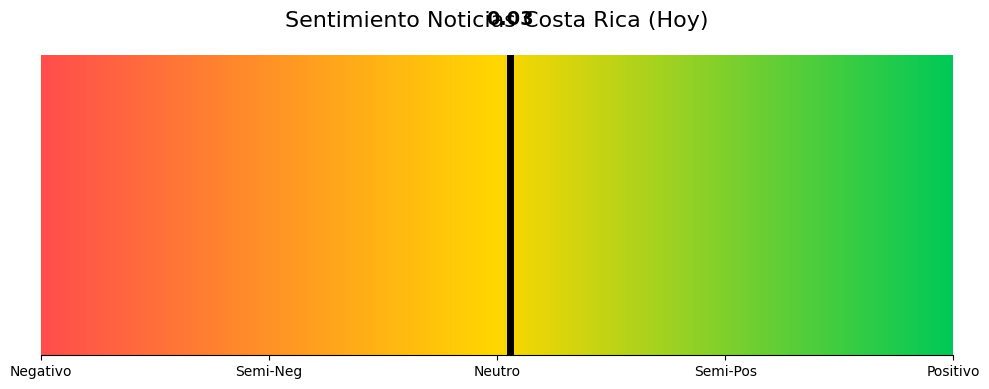

In [ ]:
import feedparser
import trafilatura
import requests
from textblob import TextBlob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from deep_translator import GoogleTranslator
from lxml import html

# --- Configuración ---
to_spanish = GoogleTranslator(source='auto', target='es')
to_english = GoogleTranslator(source='auto', target='en')

# Headers y Cookies para evitar bloqueo de Google y Muros de Pago básicos
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
    'Accept-Language': 'es-419,es;q=0.9,en;q=0.8'
}

# Cookie para saltar el popup de "Consentimiento" de Google
COOKIES = {'CONSENT': 'YES+CB'}

def obtener_url_real(google_url):
    """
    Intenta obtener la URL real destripando la página de redirección de Google.
    """
    try:
        response = requests.get(google_url, headers=HEADERS, cookies=COOKIES, timeout=10)

        # 1. Si la URL cambió mágicamente (redirección HTTP estándar)
        if "google.com" not in response.url:
            return response.url

        # 2. Si seguimos en google, buscamos el link dentro del HTML
        tree = html.fromstring(response.content)
        # Google suele poner el link en un tag <a> con clases específicas o simplemente el primer link externo
        links = tree.xpath('//a/@href')

        for link in links:
            # Filtramos links internos de google
            if link.startswith('http') and 'google.com' not in link:
                return link

        return google_url # Falló, devolvemos el original
    except Exception:
        return google_url

def get_news_data_cr(keywords):
    """
    Obtiene datos del RSS. Devuelve una lista de objetos con Título, Resumen y Link.
    """
    news_items = []
    print(f"--- 🔍 Buscando noticias en Costa Rica para {len(keywords)} temas ---")

    for keyword in keywords:
        try:
            keyword_es = to_spanish.translate(keyword)
            rss_url = f"https://news.google.com/rss/search?q={keyword_es}&hl=es-419&gl=CR&ceid=CR:es"

            feed = feedparser.parse(rss_url)

            if feed.entries:
                entry = feed.entries[0]
                # Intentamos obtener la URL real
                real_url = obtener_url_real(entry.link)

                news_items.append({
                    "keyword": keyword,
                    "title": entry.title,
                    "summary": entry.description if 'description' in entry else "",
                    "url": real_url,
                    "google_link": entry.link
                })
                print(f"[OK] {keyword} ({keyword_es})")
            else:
                print(f"[X]  {keyword} -> No se encontraron noticias.")

        except Exception as e:
            print(f"[ERROR] {keyword}: {e}")

    return news_items

def analyze_news(news_items):
    results = []
    total_sentiment = 0
    count = 0

    print("\n--- 📰 Analizando Contenido ---")

    for item in news_items:
        text_to_analyze = ""
        source_used = "Texto Completo"

        # 1. Intentar extraer texto completo con Trafilatura
        if "google.com" not in item['url']:
            try:
                downloaded = trafilatura.fetch_url(item['url'])
                if downloaded:
                    extracted = trafilatura.extract(downloaded)
                    if extracted and len(extracted) > 200:
                        text_to_analyze = extracted
            except:
                pass

        # 2. FALLBACK: Si falló la extracción (o el link seguía encriptado), usar Título + Resumen
        if not text_to_analyze:
            source_used = "Título/Resumen (Backup)"
            # Limpiamos el HTML del resumen del RSS
            clean_summary = html.fromstring(item['summary']).text_content() if item['summary'] else ""
            text_to_analyze = f"{item['title']}. {clean_summary}"

        # 3. Análisis de Sentimiento
        try:
            # Traducir a inglés para TextBlob (máx 3000 chars)
            if len(text_to_analyze) > 3000:
                text_to_analyze = text_to_analyze[:3000]

            text_en = to_english.translate(text_to_analyze)
            blob = TextBlob(text_en)
            score = blob.sentiment.polarity

            results.append({
                "keyword": item['keyword'],
                "score": score,
                "source": source_used
            })

            total_sentiment += score
            count += 1
            print(f"[ANALIZADO] {item['keyword']}: {score:.2f} ({source_used})")

        except Exception as e:
            print(f"[FALLÓ] {item['keyword']}: {e}")

    avg_sentiment = total_sentiment / count if count > 0 else 0
    return results, avg_sentiment

def create_thermometer(avg_score):
    print(f"\n--- 🌡️ Generando Termómetro (Promedio: {avg_score:.4f}) ---")

    fig, ax = plt.subplots(figsize=(10, 4))

    cmap = mcolors.LinearSegmentedColormap.from_list("", ["#ff4d4d", "#ffd700", "#00c957"])
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    gradient = np.vstack((gradient, gradient))

    ax.imshow(gradient, aspect='auto', cmap=cmap, extent=[-1, 1, 0, 1])

    ax.set_yticks([])
    ax.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax.set_xticklabels(["Negativo", "Semi-Neg", "Neutro", "Semi-Pos", "Positivo"])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    plt.axvline(x=avg_score, color='black', linestyle='-', linewidth=5)
    plt.text(avg_score, 1.1, f"{avg_score:.2f}", ha='center', fontsize=14, fontweight='bold')

    ax.set_title(f'Sentimiento Noticias Costa Rica (Hoy)', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

def main():
    keywords = [
        "Economy", "Soccer", "Tourism", "Government", "Technology",
        "Security", "Environment", "Health", "Infrastructure", "Exports"
    ]

    # 1. Obtener items
    news_items = get_news_data_cr(keywords)

    # 2. Analizar (Texto completo o Fallback)
    if news_items:
        data, avg = analyze_news(news_items)

        # 3. Reporte
        print("\n--- Resumen Final ---")
        print(f"{'Tema':<15} | {'Score':<6} | {'Fuente Usada'}")
        print("-" * 55)
        for item in data:
            print(f"{item['keyword']:<15} | {item['score']:>6.2f} | {item['source']}")

        # 4. Gráfico
        create_thermometer(avg)
    else:
        print("No se encontraron noticias.")

if __name__ == "__main__":
    main()

--- 🔍 Buscando noticias en Costa Rica (10 temas) ---
[OK] Candidates
[OK] Political
[OK] Polls
[OK] Governance
[OK] Corruption
[OK] Security
[OK] Grassroots
[OK] Whistleblower
[OK] Crackdown
[OK] Vetting

--- 📰 Procesando Datos y Métricas ---

       📊 REPORTE ESTADÍSTICO DE SENTIMIENTO CR      
Promedio General:      -0.0207
Volatilidad (StdDev):  0.1802
Intervalo Confianza:   [-0.150, 0.108] (95%)
------------------------------------------------------------
 DETECCIÓN DE ANOMALÍAS (Z-Score > 1.0 es notable)
------------------------------------------------------------
Governance      | Pol:  0.33 | Subj: 0.33 | Z:  1.96 🔥 MUY POSITIVO
Political       | Pol: -0.25 | Subj: 0.50 | Z: -1.27 📉 Negativo Notable
Vetting         | Pol:  0.20 | Subj: 0.30 | Z:  1.22 📈 Positivo Notable
Whistleblower   | Pol: -0.23 | Subj: 0.27 | Z: -1.18 📉 Negativo Notable
Grassroots      | Pol: -0.12 | Subj: 0.12 | Z: -0.58 
Polls           | Pol: -0.10 | Subj: 0.10 | Z: -0.44 
Crackdown       | Pol:  0.02 | S

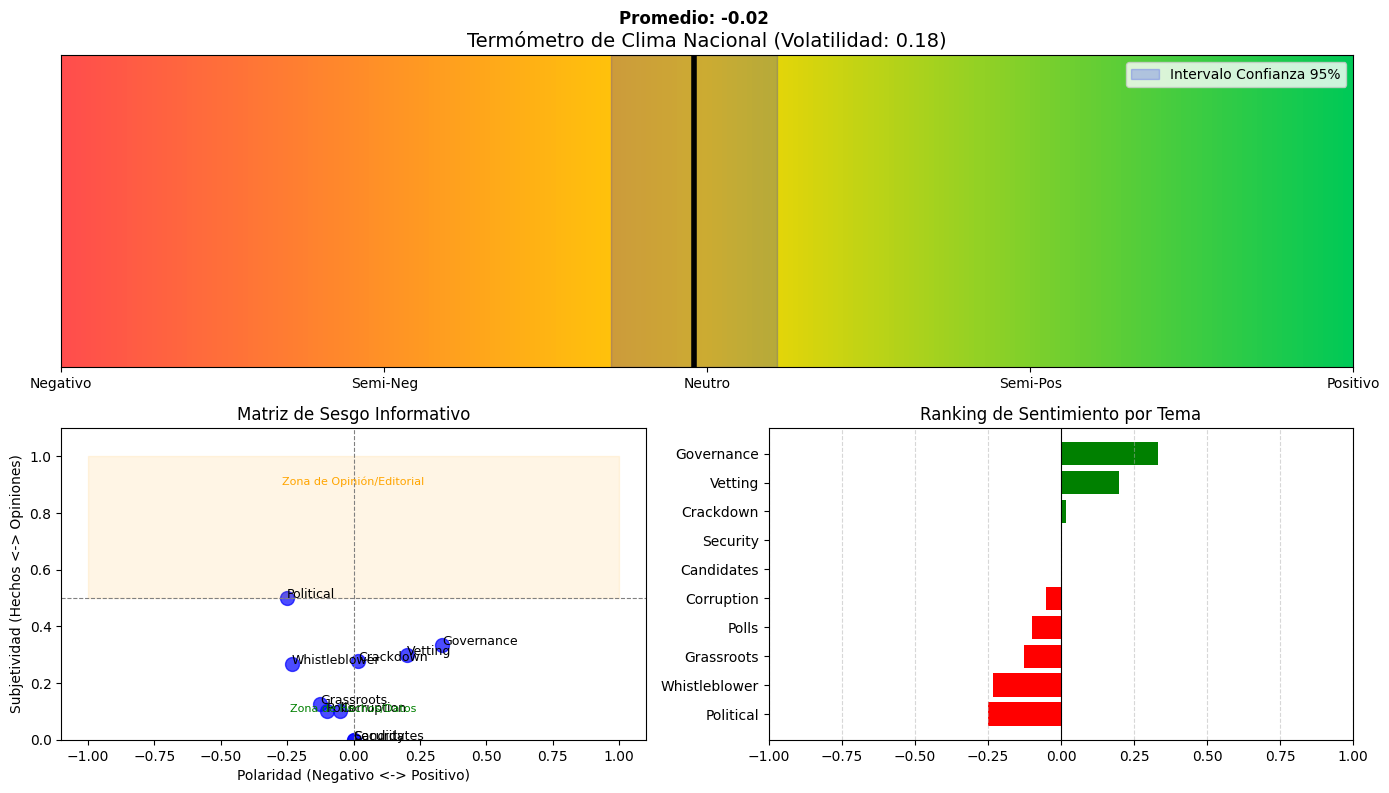

In [ ]:
import feedparser
import trafilatura
import requests
from textblob import TextBlob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from scipy import stats
from deep_translator import GoogleTranslator
from lxml import html

# --- Configuración ---
to_spanish = GoogleTranslator(source='auto', target='es')
to_english = GoogleTranslator(source='auto', target='en')

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
    'Accept-Language': 'es-419,es;q=0.9,en;q=0.8'
}
COOKIES = {'CONSENT': 'YES+CB'}

def obtener_url_real(google_url):
    try:
        response = requests.get(google_url, headers=HEADERS, cookies=COOKIES, timeout=10)
        if "google.com" not in response.url:
            return response.url
        tree = html.fromstring(response.content)
        links = tree.xpath('//a/@href')
        for link in links:
            if link.startswith('http') and 'google.com' not in link:
                return link
        return google_url
    except:
        return google_url

def get_news_data_cr(keywords):
    news_items = []
    print(f"--- 🔍 Buscando noticias en Costa Rica ({len(keywords)} temas) ---")

    for keyword in keywords:
        try:
            keyword_es = to_spanish.translate(keyword)
            rss_url = f"https://news.google.com/rss/search?q={keyword_es}&hl=es-419&gl=CR&ceid=CR:es"
            feed = feedparser.parse(rss_url)

            if feed.entries:
                entry = feed.entries[0]
                real_url = obtener_url_real(entry.link)
                news_items.append({
                    "keyword": keyword,
                    "title": entry.title,
                    "summary": entry.description if 'description' in entry else "",
                    "url": real_url
                })
                print(f"[OK] {keyword}")
            else:
                print(f"[X] {keyword}")
        except Exception as e:
            print(f"[ERROR] {keyword}: {e}")

    return news_items

def analyze_news_robust(news_items):
    data_rows = []
    print("\n--- 📰 Procesando Datos y Métricas ---")

    for item in news_items:
        text_to_analyze = ""
        source_used = "Full Text"

        # Intento de extracción
        if "google.com" not in item['url']:
            try:
                downloaded = trafilatura.fetch_url(item['url'])
                if downloaded:
                    extracted = trafilatura.extract(downloaded)
                    if extracted and len(extracted) > 200:
                        text_to_analyze = extracted
            except:
                pass

        # Fallback
        if not text_to_analyze:
            source_used = "Headline/Summary"
            clean_summary = html.fromstring(item['summary']).text_content() if item['summary'] else ""
            text_to_analyze = f"{item['title']}. {clean_summary}"

        # Análisis
        try:
            text_en = to_english.translate(text_to_analyze[:3000])
            blob = TextBlob(text_en)

            # MÉTRICAS CLAVE
            polarity = blob.sentiment.polarity         # -1 a 1 (Negativo/Positivo)
            subjectivity = blob.sentiment.subjectivity # 0 a 1 (Hecho/Opinión)

            data_rows.append({
                "Tema": item['keyword'],
                "Polaridad": polarity,
                "Subjetividad": subjectivity,
                "Fuente": source_used
            })

        except Exception:
            pass

    # Crear DataFrame para estadísticas
    df = pd.DataFrame(data_rows)
    return df

def generate_advanced_dashboard(df):
    if df.empty:
        print("No hay datos para analizar.")
        return

    # --- 1. CÁLCULOS ESTADÍSTICOS ---
    mean_pol = df['Polaridad'].mean()
    std_pol = df['Polaridad'].std()

    # Z-Score para detectar anomalías
    # Z = (X - Media) / Desviación Estándar
    # Evitamos división por cero
    if std_pol > 0:
        df['Z_Score'] = (df['Polaridad'] - mean_pol) / std_pol
    else:
        df['Z_Score'] = 0

    # Intervalo de Confianza (95%)
    # Usamos t-student por ser muestra pequeña (n < 30)
    confidence = 0.95
    degrees_freedom = len(df) - 1
    sem = stats.sem(df['Polaridad']) # Error estándar de la media
    interval = stats.t.interval(confidence, degrees_freedom, mean_pol, sem)

    print("\n=====================================================")
    print("       📊 REPORTE ESTADÍSTICO DE SENTIMIENTO CR      ")
    print("=====================================================")
    print(f"Promedio General:      {mean_pol:.4f}")
    print(f"Volatilidad (StdDev):  {std_pol:.4f}")
    print(f"Intervalo Confianza:   [{interval[0]:.3f}, {interval[1]:.3f}] (95%)")
    print("-" * 60)
    print(" DETECCIÓN DE ANOMALÍAS (Z-Score > 1.0 es notable)")
    print("-" * 60)

    # Mostrar tabla ordenada por Z-Score absoluto (los más extremos primero)
    df['Abs_Z'] = df['Z_Score'].abs()
    df_sorted = df.sort_values(by='Abs_Z', ascending=False).drop(columns=['Abs_Z'])

    for index, row in df_sorted.iterrows():
        flag = ""
        if row['Z_Score'] > 1.5: flag = "🔥 MUY POSITIVO"
        elif row['Z_Score'] < -1.5: flag = "🚨 ALERTA NEGATIVA"
        elif row['Z_Score'] > 1.0: flag = "📈 Positivo Notable"
        elif row['Z_Score'] < -1.0: flag = "📉 Negativo Notable"

        print(f"{row['Tema']:<15} | Pol: {row['Polaridad']:>5.2f} | Subj: {row['Subjetividad']:>4.2f} | Z: {row['Z_Score']:>5.2f} {flag}")

    # --- 2. VISUALIZACIÓN ---
    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 2)

    # GRÁFICO A: Termómetro Global (Arriba, ancho completo)
    ax1 = fig.add_subplot(gs[0, :])
    cmap = mcolors.LinearSegmentedColormap.from_list("", ["#ff4d4d", "#ffd700", "#00c957"])
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax1.imshow(np.vstack((gradient, gradient)), aspect='auto', cmap=cmap, extent=[-1, 1, 0, 1])
    ax1.axvline(x=mean_pol, color='black', linestyle='-', linewidth=4)
    ax1.text(mean_pol, 1.1, f"Promedio: {mean_pol:.2f}", ha='center', fontsize=12, fontweight='bold')

    # Sombreado del Intervalo de Confianza
    if not np.isnan(interval[0]):
        ax1.axvspan(max(-1, interval[0]), min(1, interval[1]), color='blue', alpha=0.2, label='Intervalo Confianza 95%')
        ax1.legend(loc='upper right')

    ax1.set_yticks([])
    ax1.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax1.set_xticklabels(["Negativo", "Semi-Neg", "Neutro", "Semi-Pos", "Positivo"])
    ax1.set_title(f'Termómetro de Clima Nacional (Volatilidad: {std_pol:.2f})', fontsize=14)

    # GRÁFICO B: Matriz de Opinión (Scatter Plot) - Abajo Izquierda
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.scatter(df['Polaridad'], df['Subjetividad'], color='blue', s=100, alpha=0.7)

    # Líneas centrales
    ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax2.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

    # Etiquetas
    for i, txt in enumerate(df['Tema']):
        ax2.annotate(txt, (df['Polaridad'].iloc[i], df['Subjetividad'].iloc[i]), fontsize=9)

    ax2.set_xlim(-1.1, 1.1)
    ax2.set_ylim(0, 1.1)
    ax2.set_xlabel('Polaridad (Negativo <-> Positivo)')
    ax2.set_ylabel('Subjetividad (Hechos <-> Opiniones)')
    ax2.set_title('Matriz de Sesgo Informativo')
    ax2.fill_between([-1, 1], 0.5, 1, color='orange', alpha=0.1) # Zona de Opinión
    ax2.text(0, 0.9, "Zona de Opinión/Editorial", ha='center', color='orange', fontsize=8)
    ax2.text(0, 0.1, "Zona de Hechos/Datos", ha='center', color='green', fontsize=8)

    # GRÁFICO C: Ranking de Temas (Barras) - Abajo Derecha
    ax3 = fig.add_subplot(gs[1, 1])
    df_rank = df.sort_values(by='Polaridad', ascending=True)
    colors = ['red' if x < 0 else 'green' for x in df_rank['Polaridad']]

    ax3.barh(df_rank['Tema'], df_rank['Polaridad'], color=colors)
    ax3.set_xlim(-1, 1)
    ax3.axvline(0, color='black', linewidth=0.8)
    ax3.set_title('Ranking de Sentimiento por Tema')
    ax3.grid(axis='x', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

def main():
    keywords = [
        "Candidates", "Political", "Polls", "Governance", "Corruption",
        "Security", "Grassroots", "Whistleblower", "Crackdown", "Vetting"
    ]

    news_items = get_news_data_cr(keywords)

    if news_items:
        df = analyze_news_robust(news_items)
        generate_advanced_dashboard(df)
    else:
        print("No se encontraron noticias.")

if __name__ == "__main__":
    main()

--- INICIANDO ANÁLISIS DE MEDIOS CR ---
Temas Clave: ['Gobierno', 'Economía', 'Seguridad', 'Turismo', 'Salud', 'Corrupción']

1. Buscando temas individuales...

2. Buscando interacciones (Cruce de temas)...
   [Encontrado] Gobierno + Economía
   [Encontrado] Gobierno + Seguridad
   [Encontrado] Gobierno + Turismo
   [Encontrado] Gobierno + Salud
   [Encontrado] Gobierno + Corrupción
   [Encontrado] Economía + Seguridad
   [Encontrado] Economía + Turismo
   [Encontrado] Economía + Salud
   [Encontrado] Economía + Corrupción
   [Encontrado] Seguridad + Turismo
   [Encontrado] Seguridad + Salud
   [Encontrado] Seguridad + Corrupción
   [Encontrado] Turismo + Salud
   [Encontrado] Turismo + Corrupción
   [Encontrado] Salud + Corrupción
--- 🇨🇷 Descargando Portada Nacional (Contexto General) ---

--- 🧠 Analizando 26 noticias (Extracción + NLP) ---

✅ Análisis completado.


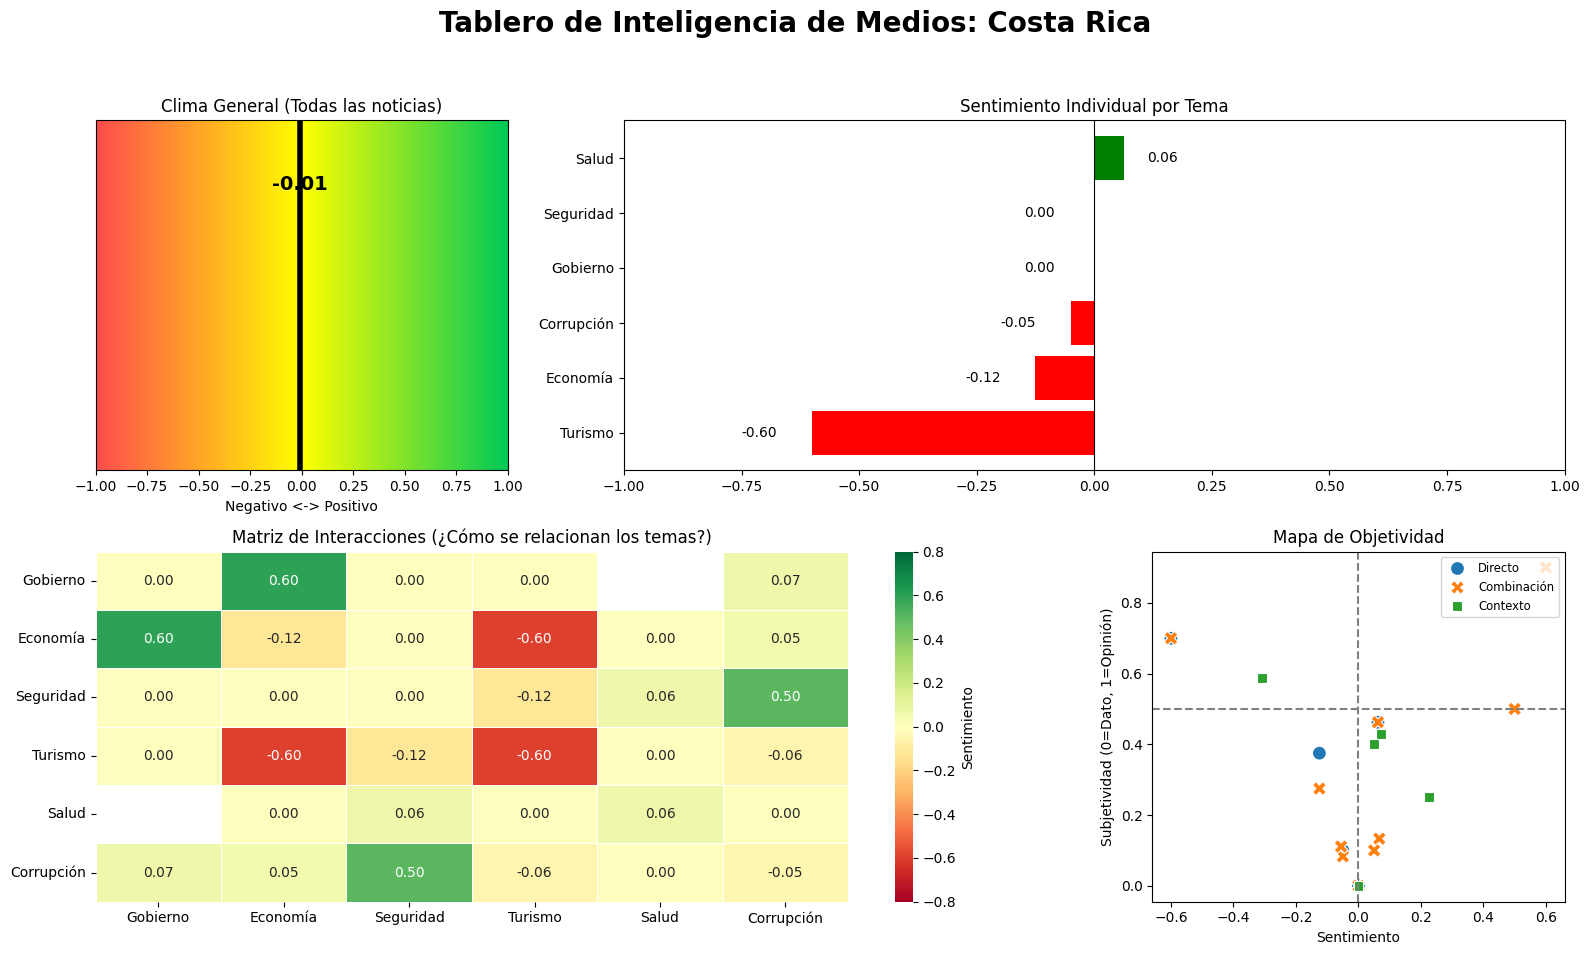


--- 🚨 ALERTA DE CRUCES CRÍTICOS (Sentimiento Negativo < -0.3) ---
🔴 CONFLICTO DETECTADO: Economía Turismo (Score: -0.60)
   Noticia: Economía - China y Japón se disputan por Taiwán: el turismo sufre y los mercados...


In [ ]:
import feedparser
import trafilatura
import requests
from textblob import TextBlob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
from deep_translator import GoogleTranslator
from lxml import html
import itertools
from urllib.parse import quote
import time

# --- CONFIGURACIÓN GLOBAL ---
# Traductor para el análisis de sentimiento (Español -> Inglés)
to_english = GoogleTranslator(source='auto', target='en')

# Headers para simular navegador y cookies para evitar bloqueos
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept-Language': 'es-419,es;q=0.9'
}
COOKIES = {'CONSENT': 'YES+CB'}

# --- FUNCIONES DE EXTRACCIÓN ---

def obtener_url_real(google_url):
    """Descifra la redirección de Google News para obtener el link del periódico."""
    try:
        response = requests.get(google_url, headers=HEADERS, cookies=COOKIES, timeout=5)
        if "google.com" not in response.url:
            return response.url
        # Intento secundario parseando HTML
        tree = html.fromstring(response.content)
        links = tree.xpath('//a/@href')
        for link in links:
            if link.startswith('http') and 'google.com' not in link:
                return link
        return google_url
    except:
        return google_url

def buscar_noticias(query, es_combinacion=False):
    """
    Busca en Google News Costa Rica.
    query: Texto a buscar (ej: "Economía" o "Economía Gobierno")
    """
    items = []
    # Codificar la query para URL (ej: espacios a %20)
    encoded_query = quote(query)

    # URL específica para Costa Rica (gl=CR, ceid=CR:es)
    rss_url = f"https://news.google.com/rss/search?q={encoded_query}&hl=es-419&gl=CR&ceid=CR:es"

    feed = feedparser.parse(rss_url)

    # Tomamos solo la noticia más relevante (Top 1) para cada combinación
    # para no saturar y mantener la relevancia de la "conexión".
    if feed.entries:
        entry = feed.entries[0]
        items.append({
            "query": query,
            "tipo": "Combinación" if es_combinacion else "Directo",
            "title": entry.title,
            "summary": entry.description if 'description' in entry else "",
            "link": entry.link,
            "pubDate": entry.published if 'published' in entry else ""
        })

    return items

def obtener_portada_cr():
    """Obtiene las noticias principales (Top Stories) de Costa Rica sin filtro de palabras."""
    print("--- 🇨🇷 Descargando Portada Nacional (Contexto General) ---")
    rss_url = "https://news.google.com/rss?hl=es-419&gl=CR&ceid=CR:es"
    feed = feedparser.parse(rss_url)
    items = []
    # Tomamos 5 noticias de portada para contexto
    for entry in feed.entries[:5]:
        items.append({
            "query": "PORTADA NACIONAL",
            "tipo": "Contexto",
            "title": entry.title,
            "summary": entry.description if 'description' in entry else "",
            "link": entry.link
        })
    return items

# --- MOTOR DE ANÁLISIS ---

def analizar_sentimiento(news_items):
    data_rows = []
    total = len(news_items)

    print(f"\n--- 🧠 Analizando {total} noticias (Extracción + NLP) ---")

    for i, item in enumerate(news_items):
        print(f"[{i+1}/{total}] Procesando: {item['query'][:30]}...", end="\r")

        text_to_analyze = ""
        real_url = obtener_url_real(item['link'])

        # 1. Intentar extracción completa
        if "google.com" not in real_url:
            try:
                downloaded = trafilatura.fetch_url(real_url)
                if downloaded:
                    extracted = trafilatura.extract(downloaded)
                    if extracted and len(extracted) > 150:
                        text_to_analyze = extracted
            except:
                pass

        # 2. Fallback a Resumen
        if not text_to_analyze:
            clean_summary = html.fromstring(item['summary']).text_content() if item['summary'] else ""
            text_to_analyze = f"{item['title']}. {clean_summary}"

        # 3. Análisis de Sentimiento
        try:
            # Traducir (límite 2500 chars para velocidad)
            text_en = to_english.translate(text_to_analyze[:2500])
            blob = TextBlob(text_en)

            data_rows.append({
                "Consulta": item['query'],
                "Tipo": item['tipo'],
                "Score": blob.sentiment.polarity,
                "Subjetividad": blob.sentiment.subjectivity,
                "Titulo": item['title']
            })
        except Exception as e:
            print(f"\nError analizando {item['query']}: {e}")

    print("\n✅ Análisis completado.")
    return pd.DataFrame(data_rows)

# --- VISUALIZACIÓN AVANZADA ---

def generar_reporte_visual(df, keywords):
    if df.empty:
        print("No hay datos suficientes.")
        return

    # Configurar el lienzo (Dashboard)
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 3)
    plt.suptitle("Tablero de Inteligencia de Medios: Costa Rica", fontsize=20, fontweight='bold')

    # 1. TERMÓMETRO GENERAL (Promedio País)
    ax1 = fig.add_subplot(gs[0, 0])
    mean_score = df['Score'].mean()

    cmap = mcolors.LinearSegmentedColormap.from_list("", ["#ff4d4d", "yellow", "#00c957"])
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax1.imshow(np.vstack((gradient, gradient)), aspect='auto', cmap=cmap, extent=[-1, 1, 0, 1])
    ax1.axvline(x=mean_score, color='black', linewidth=4)
    ax1.text(mean_score, 0.8, f"{mean_score:.2f}", ha='center', fontweight='bold', fontsize=14)
    ax1.set_yticks([])
    ax1.set_title(f"Clima General (Todas las noticias)", fontsize=12)
    ax1.set_xlabel("Negativo <-> Positivo")

    # 2. RANKING DE PALABRAS CLAVE (Solo Búsquedas Directas)
    ax2 = fig.add_subplot(gs[0, 1:])
    df_direct = df[df['Tipo'] == 'Directo'].sort_values('Score')
    if not df_direct.empty:
        colors = ['red' if x < 0 else 'green' for x in df_direct['Score']]
        bars = ax2.barh(df_direct['Consulta'], df_direct['Score'], color=colors)
        ax2.axvline(0, color='black', linewidth=0.8)
        ax2.set_title("Sentimiento Individual por Tema", fontsize=12)
        ax2.set_xlim(-1, 1)
        # Añadir etiquetas
        for bar in bars:
            width = bar.get_width()
            label_x_pos = width + 0.05 if width > 0 else width - 0.15
            ax2.text(label_x_pos, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center')

    # 3. MATRIZ DE INTERACCIONES (HEATMAP)
    # Creamos una matriz vacía NxN con las palabras clave
    ax3 = fig.add_subplot(gs[1, :2]) # Ocupa 2 columnas abajo

    matrix = pd.DataFrame(index=keywords, columns=keywords, dtype=float)

    # Llenar la matriz con los datos del DataFrame
    for k1 in keywords:
        for k2 in keywords:
            if k1 == k2:
                # Diagonal: Valor de la búsqueda individual
                val = df[df['Consulta'] == k1]['Score'].values
                matrix.loc[k1, k2] = val[0] if len(val) > 0 else 0
            else:
                # Intersección: Buscar "k1 k2" o "k2 k1"
                query1 = f"{k1} {k2}"
                query2 = f"{k2} {k1}"
                val = df[df['Consulta'].isin([query1, query2])]['Score'].values
                if len(val) > 0:
                    matrix.loc[k1, k2] = val[0]
                    matrix.loc[k2, k1] = val[0] # Simetría
                else:
                    matrix.loc[k1, k2] = np.nan

    sns.heatmap(matrix, annot=True, cmap="RdYlGn", center=0, vmin=-0.8, vmax=0.8,
                fmt=".2f", linewidths=.5, ax=ax3, cbar_kws={'label': 'Sentimiento'})
    ax3.set_title("Matriz de Interacciones (¿Cómo se relacionan los temas?)", fontsize=12)

    # 4. DISPERSIÓN SUBJETIVIDAD (Objetivo vs Opinión)
    ax4 = fig.add_subplot(gs[1, 2])
    sns.scatterplot(data=df, x='Score', y='Subjetividad', hue='Tipo', style='Tipo', s=100, ax=ax4)
    ax4.axvline(0, color='gray', linestyle='--')
    ax4.axhline(0.5, color='gray', linestyle='--')
    ax4.set_title("Mapa de Objetividad", fontsize=12)
    ax4.set_ylabel("Subjetividad (0=Dato, 1=Opinión)")
    ax4.set_xlabel("Sentimiento")
    ax4.legend(loc='upper right', fontsize='small')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Imprimir datos destacados
    print("\n--- 🚨 ALERTA DE CRUCES CRÍTICOS (Sentimiento Negativo < -0.3) ---")
    conflictos = df[(df['Tipo'] == 'Combinación') & (df['Score'] < -0.3)]
    if not conflictos.empty:
        for _, row in conflictos.iterrows():
            print(f"🔴 CONFLICTO DETECTADO: {row['Consulta']} (Score: {row['Score']:.2f})")
            print(f"   Noticia: {row['Titulo'][:80]}...")
    else:
        print("No se detectaron interacciones altamente negativas.")

# --- EJECUCIÓN PRINCIPAL ---

def main():
    # 1. DEFINICIÓN DE TEMAS (En Español, como solicitaste)
    # NOTA: Mantener máximo 6-7 temas para evitar tiempos de espera largos (combinatorias crecen rápido)
    keywords_es = [
        "Gobierno",
        "Economía",
        "Seguridad",
        "Turismo",
        "Salud",
        "Corrupción"
    ]

    print(f"--- INICIANDO ANÁLISIS DE MEDIOS CR ---")
    print(f"Temas Clave: {keywords_es}")

    all_results = []

    # 2. BÚSQUEDA INDIVIDUAL
    print("\n1. Buscando temas individuales...")
    for word in keywords_es:
        res = buscar_noticias(word, es_combinacion=False)
        all_results.extend(res)
        time.sleep(0.5) # Pausa ética para no saturar Google

    # 3. BÚSQUEDA DE COMBINACIONES (Relaciones)
    print("\n2. Buscando interacciones (Cruce de temas)...")
    # itertools.combinations genera pares únicos: (Gobierno, Economía), (Gobierno, Seguridad)...
    pairs = list(itertools.combinations(keywords_es, 2))

    for k1, k2 in pairs:
        query = f"{k1} {k2}"
        res = buscar_noticias(query, es_combinacion=True)
        if not res: # Si no hay noticia exacta de la combinación, buscar con AND
             res = buscar_noticias(f"{k1} AND {k2}", es_combinacion=True)

        if res:
            all_results.extend(res)
            print(f"   [Encontrado] {k1} + {k2}")
        else:
            print(f"   [Sin datos]  {k1} + {k2}")
        time.sleep(0.5)

    # 4. BÚSQUEDA DE CONTEXTO NACIONAL
    portada = obtener_portada_cr()
    all_results.extend(portada)

    # 5. PROCESAMIENTO Y VISUALIZACIÓN
    if all_results:
        df = analizar_sentimiento(all_results)
        generar_reporte_visual(df, keywords_es)
    else:
        print("Error crítico: No se pudieron recuperar noticias.")

if __name__ == "__main__":
    main()

In [ ]:
import feedparser
import trafilatura
import requests
from textblob import TextBlob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd
from deep_translator import GoogleTranslator
from lxml import html
import itertools
from urllib.parse import quote, urlparse
import time

# --- CONFIGURACIÓN ---
to_english = GoogleTranslator(source='auto', target='es') # Correction: target='en' internally for analysis
translator_en = GoogleTranslator(source='auto', target='en')

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept-Language': 'es-419,es;q=0.9'
}
COOKIES = {'CONSENT': 'YES+CB'}

# --- FILTRO DE MEDIOS TICOS ---
# Lista de dominios que NO terminan en .cr pero son ticos
MEDIOS_TICOS_CONFIABLES = [
    "nacion.com", "crhoy.com", "teletica.com", "diarioextra.com",
    "larepublica.net", "elfinancierocr.com", "semanariouniversidad.com",
    "ameliarueda.com", "monumental.co.cr", "columbia.co.cr",
    "observador.cr", "elmundo.cr", "culturacr.net", "delfino.cr",
    "lateja.cr", "qcostarica.com", "ticotimes.net", "bsnoticias.cr"
]

def es_medio_costarricense(url):
    """
    Valida si la URL pertenece a un medio de Costa Rica.
    1. Verifica si el dominio termina en .cr
    2. Verifica si está en la lista blanca de medios ticos (.com, .net)
    """
    try:
        domain = urlparse(url).netloc.lower()

        # Criterio 1: Dominio nacional
        if domain.endswith(".cr"):
            return True, domain

        # Criterio 2: Lista blanca (para nacion.com, crhoy.com, etc)
        for medio in MEDIOS_TICOS_CONFIABLES:
            if medio in domain:
                return True, domain

        return False, domain
    except:
        return False, "desconocido"

# --- FUNCIONES DE EXTRACCIÓN ---

def obtener_url_real(google_url):
    try:
        response = requests.get(google_url, headers=HEADERS, cookies=COOKIES, timeout=5)
        if "google.com" not in response.url:
            return response.url
        tree = html.fromstring(response.content)
        links = tree.xpath('//a/@href')
        for link in links:
            if link.startswith('http') and 'google.com' not in link:
                return link
        return google_url
    except:
        return google_url

def buscar_noticias_cr_verificadas(query, es_combinacion=False):
    items = []
    encoded_query = quote(query)
    # Forzamos región CR
    rss_url = f"https://news.google.com/rss/search?q={encoded_query}&hl=es-419&gl=CR&ceid=CR:es"

    feed = feedparser.parse(rss_url)

    # Buscamos hasta encontrar UNA noticia que sea realmente tica
    # A veces la #1 es internacional, así que iteramos las primeras 3
    found = False
    for entry in feed.entries[:5]:
        if found: break

        real_url = obtener_url_real(entry.link)
        es_tica, dominio = es_medio_costarricense(real_url)

        if es_tica:
            items.append({
                "query": query,
                "tipo": "Combinación" if es_combinacion else "Directo",
                "title": entry.title,
                "summary": entry.description if 'description' in entry else "",
                "link": real_url,
                "source": dominio  # Guardamos el medio para el reporte
            })
            found = True # Solo tomamos la mejor noticia Tica por tema

    return items

# --- ANÁLISIS ---

def analizar_sentimiento(news_items):
    data_rows = []
    total = len(news_items)
    print(f"\n--- 🧠 Analizando {total} noticias validadas de Costa Rica ---")

    for i, item in enumerate(news_items):
        print(f"[{i+1}/{total}] {item['source'][:15]}... | Tema: {item['query']}", end="\r")

        text_to_analyze = ""

        # 1. Trafilatura (Extracción)
        try:
            downloaded = trafilatura.fetch_url(item['link'])
            if downloaded:
                extracted = trafilatura.extract(downloaded)
                if extracted and len(extracted) > 150:
                    text_to_analyze = extracted
        except: pass

        # 2. Fallback
        if not text_to_analyze:
            clean_summary = html.fromstring(item['summary']).text_content() if item['summary'] else ""
            text_to_analyze = f"{item['title']}. {clean_summary}"

        # 3. NLP
        try:
            # Traducir a Inglés para el motor de sentimiento
            text_en = translator_en.translate(text_to_analyze[:2500])
            blob = TextBlob(text_en)

            data_rows.append({
                "Consulta": item['query'],
                "Tipo": item['tipo'],
                "Score": blob.sentiment.polarity,
                "Subjetividad": blob.sentiment.subjectivity,
                "Medio": item['source'],
                "Titulo": item['title']
            })
        except Exception as e:
            pass

    print("\n✅ Análisis finalizado.")
    return pd.DataFrame(data_rows)

# --- VISUALIZACIÓN (Igual que antes pero con etiqueta de medio) ---

def generar_reporte_visual(df, keywords):
    if df.empty: return

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 3)
    plt.suptitle(f"Inteligencia de Medios Costa Rica (Fuentes Verificadas)", fontsize=20)

    # 1. Termómetro
    ax1 = fig.add_subplot(gs[0, 0])
    mean_score = df['Score'].mean()
    cmap = mcolors.LinearSegmentedColormap.from_list("", ["#ff4d4d", "yellow", "#00c957"])
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax1.imshow(np.vstack((gradient, gradient)), aspect='auto', cmap=cmap, extent=[-1, 1, 0, 1])
    ax1.axvline(x=mean_score, color='black', linewidth=4)
    ax1.text(mean_score, 0.8, f"{mean_score:.2f}", ha='center', fontweight='bold', fontsize=14)
    ax1.set_yticks([])
    ax1.set_title(f"Sentimiento País (N={len(df)})")

    # 2. Barras por Tema
    ax2 = fig.add_subplot(gs[0, 1:])
    df_direct = df[df['Tipo'] == 'Directo'].sort_values('Score')
    if not df_direct.empty:
        colors = ['red' if x < 0 else 'green' for x in df_direct['Score']]
        bars = ax2.barh(df_direct['Consulta'], df_direct['Score'], color=colors)
        ax2.axvline(0, color='black', linewidth=0.8)
        ax2.set_title("Sentimiento por Tema")
        ax2.set_xlim(-1, 1)

    # 3. Matriz Heatmap
    ax3 = fig.add_subplot(gs[1, :2])
    matrix = pd.DataFrame(index=keywords, columns=keywords, dtype=float)
    for k1 in keywords:
        for k2 in keywords:
            if k1 == k2:
                val = df[df['Consulta'] == k1]['Score'].values
                matrix.loc[k1, k2] = val[0] if len(val) > 0 else 0
            else:
                query1, query2 = f"{k1} {k2}", f"{k2} {k1}"
                val = df[df['Consulta'].isin([query1, query2])]['Score'].values
                if len(val) > 0:
                    matrix.loc[k1, k2] = val[0]
                    matrix.loc[k2, k1] = val[0]
                else:
                    matrix.loc[k1, k2] = np.nan
    sns.heatmap(matrix, annot=True, cmap="RdYlGn", center=0, vmin=-0.8, vmax=0.8, ax=ax3)
    ax3.set_title("Matriz de Interacciones (Cruce de Temas)")

    # 4. Distribución de Medios (NUEVO)
    ax4 = fig.add_subplot(gs[1, 2])
    medios_count = df['Medio'].value_counts().head(5)
    medios_count.plot(kind='pie', autopct='%1.1f%%', ax=ax4, startangle=90, cmap="Pastel1")
    ax4.set_ylabel('')
    ax4.set_title("Fuentes Utilizadas")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\n--- 📋 DETALLE DE NOTICIAS ANALIZADAS ---")
    print(f"{'MEDIO':<20} | {'TEMA':<20} | {'SCORE':<6} | {'TITULO'}")
    print("-" * 80)
    for _, row in df.iterrows():
        sc_str = f"{row['Score']:.2f}"
        print(f"{row['Medio']:<20} | {row['Consulta'][:20]:<20} | {sc_str:<6} | {row['Titulo'][:40]}...")

def main():
    # Temas a investigar
    keywords_es = [
        "Gobierno", "Economía", "Seguridad",
        "Turismo", "Salud", "Corrupción"
    ]

    print(f"--- 🕵️ INICIANDO RASTREO VERIFICADO EN COSTA RICA ---")
    all_results = []

    # 1. Individuales
    print("1. Buscando temas principales...")
    for word in keywords_es:
        res = buscar_noticias_cr_verificadas(word, es_combinacion=False)
        if res:
            print(f"   ✅ {word} -> Fuente: {res[0]['source']}")
        else:
            print(f"   ❌ {word} -> No se halló fuente 100% tica verificada.")
        all_results.extend(res)
        time.sleep(0.5)

    # 2. Combinaciones
    print("\n2. Cruzando variables...")
    pairs = list(itertools.combinations(keywords_es, 2))
    for k1, k2 in pairs:
        query = f"{k1} {k2}"
        res = buscar_noticias_cr_verificadas(query, es_combinacion=True)

        # Si no hay con espacio, probar con AND
        if not res:
             res = buscar_noticias_cr_verificadas(f"{k1} AND {k2}", es_combinacion=True)

        if res:
            all_results.extend(res)
            print(f"   ✅ {k1} + {k2}")
        else:
            # Opcional: no imprimir nada para no ensuciar la consola
            pass
        time.sleep(0.5)

    # 3. Procesar
    if all_results:
        df = analizar_sentimiento(all_results)
        generar_reporte_visual(df, keywords_es)
    else:
        print("No se encontraron noticias de medios costarricenses verificados.")

if __name__ == "__main__":
    main()

--- 🕵️ INICIANDO RASTREO VERIFICADO EN COSTA RICA ---
1. Buscando temas principales...
   ❌ Gobierno -> No se halló fuente 100% tica verificada.
   ❌ Economía -> No se halló fuente 100% tica verificada.
   ❌ Seguridad -> No se halló fuente 100% tica verificada.
   ❌ Turismo -> No se halló fuente 100% tica verificada.
   ❌ Salud -> No se halló fuente 100% tica verificada.
   ❌ Corrupción -> No se halló fuente 100% tica verificada.

2. Cruzando variables...
No se encontraron noticias de medios costarricenses verificados.


In [ ]:
import feedparser
import trafilatura
import requests
from textblob import TextBlob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd
from deep_translator import GoogleTranslator
from lxml import html
import itertools
from urllib.parse import quote, urlparse
import time

# --- 1. CONFIGURACIÓN Y LISTA VIP ---

# Traductor
translator_en = GoogleTranslator(source='auto', target='en')

# Headers Anti-Bloqueo
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept-Language': 'es-419,es;q=0.9'
}
COOKIES = {'CONSENT': 'YES+CB'}

# TU LISTA DE MEDIOS OBJETIVO (Limpiamos las URLs para dejar solo el dominio)
MEDIOS_VIP = [
    "nacion.com",
    "crhoy.com",
    "monumental.co.cr",
    "delfino.cr",
    "semanariouniversidad.com",
    "ameliarueda.com",
    "columbia.co.cr",
    "teletica.com",
    "repretel.com"
]

# Construimos el filtro "OR" para la búsqueda
# Esto crea un string tipo: "site:nacion.com OR site:crhoy.com OR ..."
FILTRO_SITIOS = " OR ".join([f"site:{m}" for m in MEDIOS_VIP])

# --- 2. FUNCIONES DE RECUPERACIÓN ---

def obtener_url_real(google_url):
    """
    Intenta resolver la redirección de Google para obtener el link directo al medio.
    """
    try:
        # Timeout corto para no atrasar el proceso
        response = requests.get(google_url, headers=HEADERS, cookies=COOKIES, timeout=4)

        # Si la URL final ya no es google, ganamos
        if "google.com" not in response.url:
            return response.url

        # Si sigue siendo google, intentamos extraer del HTML
        tree = html.fromstring(response.content)
        links = tree.xpath('//a/@href')
        for link in links:
            # Buscamos el primer link que no sea de google y empiece por http
            if link.startswith('http') and 'google.com' not in link:
                return link

        return google_url
    except:
        return google_url

def buscar_en_medios_vip(keyword, es_combinacion=False):
    """
    Busca la keyword EXCLUSIVAMENTE en los sitios definidos en MEDIOS_VIP.
    """
    items = []

    # Construimos la Query Maestra:  "Economía (site:nacion.com OR site:crhoy.com ...)"
    query_avanzada = f'{keyword} ({FILTRO_SITIOS})'
    encoded_query = quote(query_avanzada)

    # URL del RSS filtrado
    rss_url = f"https://news.google.com/rss/search?q={encoded_query}&hl=es-419&gl=CR&ceid=CR:es"

    feed = feedparser.parse(rss_url)

    # Procesamos los resultados (Tomamos Top 2 para tener variedad de fuentes)
    for entry in feed.entries[:2]:
        real_url = obtener_url_real(entry.link)

        # Identificar de qué medio vino
        domain = urlparse(real_url).netloc.lower()
        nombre_medio = "Desconocido"
        for m in MEDIOS_VIP:
            if m in domain:
                nombre_medio = m
                break

        # Solo agregamos si logramos identificar que viene de nuestra lista (o subdominios)
        # A veces Google cuela algo, esto es un doble filtro de seguridad.
        if nombre_medio != "Desconocido" or any(vip in domain for vip in MEDIOS_VIP):
            items.append({
                "query": keyword,
                "tipo": "Combinación" if es_combinacion else "Directo",
                "title": entry.title,
                "summary": entry.description if 'description' in entry else "",
                "link": real_url,
                "source": nombre_medio
            })

            # Si es una combinación, con 1 resultado basta para probar la conexión
            if es_combinacion:
                break

    return items

# --- 3. ANÁLISIS Y NLP ---

def analizar_contenido(items):
    data = []
    total = len(items)
    print(f"\n--- ⚙️ Procesando {total} artículos de fuentes oficiales ---")

    for i, item in enumerate(items):
        print(f"[{i+1}/{total}] {item['source'][:15]}... | {item['query']}", end="\r")

        texto_analisis = ""

        # A. Intentar descargar el artículo completo (Trafilatura)
        try:
            downloaded = trafilatura.fetch_url(item['link'])
            if downloaded:
                extracted = trafilatura.extract(downloaded)
                if extracted and len(extracted) > 200:
                    texto_analisis = extracted
        except: pass

        # B. Fallback: Usar título y resumen si falla la descarga
        source_type = "Texto Completo"
        if not texto_analisis:
            source_type = "Resumen"
            clean_sum = html.fromstring(item['summary']).text_content() if item['summary'] else ""
            texto_analisis = f"{item['title']}. {clean_sum}"

        # C. Análisis de Sentimiento
        try:
            # Traducir para TextBlob (limitado a 3000 chars para velocidad)
            txt_en = translator_en.translate(texto_analisis[:3000])
            blob = TextBlob(txt_en)

            data.append({
                "Consulta": item['query'],
                "Tipo": item['tipo'],
                "Score": blob.sentiment.polarity,      # -1 a 1
                "Subjetividad": blob.sentiment.subjectivity, # 0 a 1
                "Medio": item['source'],
                "Metodo": source_type,
                "Titulo": item['title']
            })
        except Exception as e:
            pass # Ignorar errores de traducción puntuales

    return pd.DataFrame(data)

# --- 4. VISUALIZACIÓN COMPLETA ---

def visualizar_dashboard(df, keywords):
    if df.empty:
        print("❌ No hay datos para graficar.")
        return

    # Configuración del Lienzo
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 3)
    plt.suptitle("Monitor de Medios Costa Rica (Fuentes VIP)", fontsize=22, fontweight='bold')

    # GRAFICO 1: Termómetro General
    ax1 = fig.add_subplot(gs[0, 0])
    avg = df['Score'].mean()
    cmap = mcolors.LinearSegmentedColormap.from_list("", ["#d9534f", "#f0ad4e", "#5cb85c"])
    grad = np.linspace(0, 1, 256).reshape(1, -1)
    ax1.imshow(np.vstack((grad, grad)), aspect='auto', cmap=cmap, extent=[-1, 1, 0, 1])
    ax1.axvline(avg, color='black', linewidth=4)
    ax1.text(avg, 0.8, f"{avg:.2f}", ha='center', fontsize=16, fontweight='bold')
    ax1.set_title("Sentimiento Promedio País")
    ax1.set_yticks([])

    # GRAFICO 2: Sentimiento por Medio (¿Quién es más negativo?)
    ax2 = fig.add_subplot(gs[0, 1])
    medios_score = df.groupby('Medio')['Score'].mean().sort_values()
    colors = ['#d9534f' if x < 0 else '#5cb85c' for x in medios_score.values]
    medios_score.plot(kind='barh', color=colors, ax=ax2)
    ax2.set_title("Sesgo Editorial por Medio (Promedio)")
    ax2.set_xlim(-0.8, 0.8)
    ax2.axvline(0, color='black', linewidth=0.5)

    # GRAFICO 3: Distribución de Cobertura (Pie Chart)
    ax3 = fig.add_subplot(gs[0, 2])
    df['Medio'].value_counts().plot(kind='pie', autopct='%1.0f%%', ax=ax3, cmap="Set3")
    ax3.set_ylabel('')
    ax3.set_title("Share of Voice (Volumen de Noticias)")

    # GRAFICO 4: Matriz de Interacciones (Heatmap)
    ax4 = fig.add_subplot(gs[1, :]) # Ocupa toda la fila de abajo

    # Construir matriz NxN
    matrix = pd.DataFrame(index=keywords, columns=keywords, dtype=float)
    for k1 in keywords:
        for k2 in keywords:
            if k1 == k2:
                val = df[df['Consulta'] == k1]['Score'].mean() # Usamos mean por si hay varias
                matrix.loc[k1, k2] = val
            else:
                # Buscar coincidencia en cualquier orden
                mask = df['Consulta'].isin([f"{k1} {k2}", f"{k2} {k1}", f"{k1} AND {k2}"])
                val = df[mask]['Score'].mean()
                if not np.isnan(val):
                    matrix.loc[k1, k2] = val
                    matrix.loc[k2, k1] = val

    sns.heatmap(matrix, annot=True, cmap="RdYlGn", center=0, vmin=-0.6, vmax=0.6, ax=ax4)
    ax4.set_title("Matriz de Conexiones: ¿Cómo se relacionan los temas?")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Reporte de Texto
    print("\n" + "="*80)
    print(f"{'MEDIO':<20} | {'TEMA / CRUCE':<25} | {'SCORE':<6} | {'TITULO'}")
    print("="*80)
    for _, row in df.iterrows():
        print(f"{row['Medio'][:20]:<20} | {row['Consulta'][:25]:<25} | {row['Score']:>5.2f}  | {row['Titulo'][:50]}...")

# --- 5. EJECUCIÓN ---

def main():
    # TEMAS A INVESTIGAR
    keywords = ["Partidos", "Politicos", "Corrupción", "Inseguridad", "Gobierno"]

    print("--- 🕵️ INICIANDO MONITOR DE MEDIOS VIP ---")
    print(f"Fuentes: {', '.join(MEDIOS_VIP)}")
    print(f"Temas: {keywords}\n")

    all_items = []

    # A. Búsqueda Individual
    print(">> Buscando temas individuales...")
    for k in keywords:
        res = buscar_en_medios_vip(k, es_combinacion=False)
        all_items.extend(res)
        time.sleep(1) # Pausa para evitar bloqueo

    # B. Búsqueda Combinada (Interacciones)
    print("\n>> Buscando cruces de temas...")
    pairs = list(itertools.combinations(keywords, 2))
    for k1, k2 in pairs:
        # Buscamos "Tema1 Tema2"
        query = f"{k1} {k2}"
        res = buscar_en_medios_vip(query, es_combinacion=True)
        if res:
            all_items.extend(res)
            print(f"   [✔] Encontrado: {k1} + {k2}")
        else:
            # Intento secundario con AND explícito
            res = buscar_en_medios_vip(f"{k1} AND {k2}", es_combinacion=True)
            if res:
                all_items.extend(res)
                print(f"   [✔] Encontrado: {k1} + {k2} (vía AND)")
            else:
                print(f"   [ ] Sin conexión: {k1} + {k2}")
        time.sleep(1)

    # C. Procesar
    if all_items:
        df = analizar_contenido(all_items)
        visualizar_dashboard(df, keywords)
    else:
        print("No se encontraron noticias en los medios seleccionados para estos temas.")

if __name__ == "__main__":
    main()

--- 🕵️ INICIANDO MONITOR DE MEDIOS VIP ---
Fuentes: nacion.com, crhoy.com, monumental.co.cr, delfino.cr, semanariouniversidad.com, ameliarueda.com, columbia.co.cr, teletica.com, repretel.com
Temas: ['Partidos', 'Politicos', 'Corrupción', 'Inseguridad', 'Gobierno']

>> Buscando temas individuales...

>> Buscando cruces de temas...
   [ ] Sin conexión: Partidos + Politicos
   [ ] Sin conexión: Partidos + Corrupción
   [ ] Sin conexión: Partidos + Inseguridad
   [ ] Sin conexión: Partidos + Gobierno
   [ ] Sin conexión: Politicos + Corrupción
   [ ] Sin conexión: Politicos + Inseguridad
   [ ] Sin conexión: Politicos + Gobierno
   [ ] Sin conexión: Corrupción + Inseguridad
   [ ] Sin conexión: Corrupción + Gobierno
   [ ] Sin conexión: Inseguridad + Gobierno
No se encontraron noticias en los medios seleccionados para estos temas.


In [ ]:
import feedparser
import trafilatura
import requests
from textblob import TextBlob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd
from deep_translator import GoogleTranslator
from lxml import html
import itertools
from urllib.parse import quote, urlparse
import time

# --- 1. CONFIGURACIÓN ---

translator_en = GoogleTranslator(source='auto', target='en')

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept-Language': 'es-419,es;q=0.9'
}
COOKIES = {'CONSENT': 'YES+CB'}

# TU LISTA BLANCA (Solo aceptaremos noticias de estos dominios)
VIP_DOMAINS = [
    "nacion.com",
    "crhoy.com",
    "monumental.co.cr",
    "delfino.cr",
    "semanariouniversidad.com",
    "ameliarueda.com",
    "columbia.co.cr",
    "teletica.com",
    "repretel.com",
    "diarioextra.com",
    "larepublica.net",
    "elmundo.cr",
    "observador.cr"
]

# --- 2. FUNCIONES DE BÚSQUEDA ROBUSTA ---

def resolver_url_final(google_url):
    """
    Sigue la redirección para ver si la URL final es de un medio VIP.
    """
    try:
        # Timeout bajo para velocidad
        response = requests.get(google_url, headers=HEADERS, cookies=COOKIES, timeout=3)
        final_url = response.url

        # Si falló la redirección automática, intentamos scraping básico del link
        if "google.com" in final_url:
            try:
                tree = html.fromstring(response.content)
                links = tree.xpath('//a/@href')
                for link in links:
                    if link.startswith('http') and 'google.com' not in link:
                        return link
            except:
                pass
        return final_url
    except:
        return google_url

def buscar_y_filtrar(keyword, es_combinacion=False):
    """
    Estrategia:
    1. Busca en Google News CR general.
    2. Filtra en memoria (Python) comparando contra VIP_DOMAINS.
    """
    items = []
    # Búsqueda general en Costa Rica (gl=CR)
    query_encoded = quote(keyword)
    rss_url = f"https://news.google.com/rss/search?q={query_encoded}&hl=es-419&gl=CR&ceid=CR:es"

    feed = feedparser.parse(rss_url)

    # Si no hay entradas, retornamos vacío
    if not feed.entries:
        return []

    # Recorremos los resultados (analizamos hasta 15 para encontrar matches VIP)
    count_found = 0
    limit = 2 if not es_combinacion else 1 # Cuántas noticias queremos guardar por tema

    for entry in feed.entries[:15]: # Miramos los primeros 15
        if count_found >= limit: break

        # 1. Obtener URL Real
        real_url = resolver_url_final(entry.link)
        domain = urlparse(real_url).netloc.lower()

        # 2. VERIFICAR SI ES VIP
        es_vip = False
        medio_detectado = "Desconocido"

        for vip in VIP_DOMAINS:
            if vip in domain:
                es_vip = True
                medio_detectado = vip
                break

        # Solo guardamos si está en la lista VIP
        if es_vip:
            items.append({
                "query": keyword,
                "tipo": "Combinación" if es_combinacion else "Directo",
                "title": entry.title,
                "summary": entry.description if 'description' in entry else "",
                "link": real_url,
                "source": medio_detectado
            })
            count_found += 1

    return items

# --- 3. ANÁLISIS ---

def procesar_noticias(items):
    data = []
    total = len(items)
    print(f"\n--- ⚙️ Analizando {total} noticias verificadas ---")

    for i, item in enumerate(items):
        print(f"[{i+1}/{total}] {item['source'][:15]}... | {item['query'][:20]}", end="\r")

        texto_completo = ""
        # Intentar descargar texto
        try:
            downloaded = trafilatura.fetch_url(item['link'])
            if downloaded:
                extracted = trafilatura.extract(downloaded)
                if extracted and len(extracted) > 200:
                    texto_completo = extracted
        except: pass

        # Fallback a resumen
        if not texto_completo:
            clean_sum = html.fromstring(item['summary']).text_content() if item['summary'] else ""
            texto_completo = f"{item['title']}. {clean_sum}"

        # Sentimiento
        try:
            txt_en = translator_en.translate(texto_completo[:2500])
            blob = TextBlob(txt_en)
            data.append({
                "Consulta": item['query'],
                "Tipo": item['tipo'],
                "Score": blob.sentiment.polarity,
                "Medio": item['source'],
                "Titulo": item['title']
            })
        except: pass

    return pd.DataFrame(data)

# --- 4. VISUALIZACIÓN ---

def dashboard_final(df, keywords):
    if df.empty: return

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 3)
    plt.suptitle("Monitor de Inteligencia (Solo Fuentes Ticas)", fontsize=18)

    # A. Termómetro
    ax1 = fig.add_subplot(gs[0, 0])
    avg = df['Score'].mean()
    cmap = mcolors.LinearSegmentedColormap.from_list("", ["red", "yellow", "green"])
    grad = np.linspace(0, 1, 256).reshape(1, -1)
    ax1.imshow(np.vstack((grad, grad)), aspect='auto', cmap=cmap, extent=[-1, 1, 0, 1])
    ax1.axvline(avg, color='black', linewidth=3)
    ax1.set_title(f"Sentimiento Promedio: {avg:.2f}")
    ax1.set_yticks([])

    # B. Barras por Medio
    ax2 = fig.add_subplot(gs[0, 1])
    if 'Medio' in df.columns:
        df.groupby('Medio')['Score'].mean().sort_values().plot(kind='barh', ax=ax2, color='skyblue')
        ax2.set_title("Sentimiento por Medio")
        ax2.axvline(0, color='black', linewidth=0.5)

    # C. Matriz Heatmap
    ax3 = fig.add_subplot(gs[1, :])
    matrix = pd.DataFrame(index=keywords, columns=keywords, dtype=float)
    for k1 in keywords:
        for k2 in keywords:
            if k1 == k2:
                val = df[df['Consulta'] == k1]['Score'].mean()
                matrix.loc[k1, k2] = val
            else:
                # Buscar A B, B A, A AND B
                mask = df['Consulta'].isin([f"{k1} {k2}", f"{k2} {k1}", f"{k1} AND {k2}"])
                val = df[mask]['Score'].mean()
                if not np.isnan(val):
                    matrix.loc[k1, k2] = val
                    matrix.loc[k2, k1] = val

    sns.heatmap(matrix, annot=True, cmap="RdYlGn", center=0, vmin=-0.6, vmax=0.6, ax=ax3)
    ax3.set_title("Mapa de Calor de Interacciones")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\n" + "="*60)
    print(f"{'MEDIO':<20} | {'TEMA':<20} | {'SCORE':<6} | {'TITULO'}")
    print("="*60)
    for _, row in df.iterrows():
        print(f"{row['Medio'][:20]:<20} | {row['Consulta'][:20]:<20} | {row['Score']:>5.2f}  | {row['Titulo'][:40]}...")

# --- 5. EJECUCIÓN ---

def main():
    # TUS TEMAS
    keywords = ['Partidos', 'Politicos', 'Corrupción', 'Inseguridad', 'Gobierno']

    print(f"--- 🕵️ MONITOR VIP: {len(VIP_DOMAINS)} FUENTES ---")
    all_items = []

    # 1. Individuales
    print(">> Fase 1: Búsqueda Individual")
    for k in keywords:
        res = buscar_y_filtrar(k, es_combinacion=False)
        if res:
            print(f"   ✅ {k}: {len(res)} noticias encontradas (ej. {res[0]['source']})")
            all_items.extend(res)
        else:
            print(f"   ⚠️ {k}: Google encontró noticias, pero ninguna de tu lista VIP.")
        time.sleep(1)

    # 2. Combinaciones
    print("\n>> Fase 2: Interacciones (Cruces)")
    pairs = list(itertools.combinations(keywords, 2))
    for k1, k2 in pairs:
        query = f"{k1} {k2}"
        res = buscar_y_filtrar(query, es_combinacion=True)

        if not res:
            # Intento con AND
            res = buscar_y_filtrar(f"{k1} AND {k2}", es_combinacion=True)

        if res:
            print(f"   🔗 {k1} + {k2}: Encontrado en {res[0]['source']}")
            all_items.extend(res)
        else:
            # Opcional: reducir ruido en consola
            pass
        time.sleep(1)

    # 3. Resultado
    if all_items:
        df = procesar_noticias(all_items)
        dashboard_final(df, keywords)
    else:
        print("\n❌ Resultado: 0 Noticias.")
        print("Consejo: Intenta palabras clave más generales si la intersección es muy específica.")

if __name__ == "__main__":
    main()

--- 🕵️ MONITOR VIP: 13 FUENTES ---
>> Fase 1: Búsqueda Individual
   ⚠️ Partidos: Google encontró noticias, pero ninguna de tu lista VIP.
   ⚠️ Politicos: Google encontró noticias, pero ninguna de tu lista VIP.
   ⚠️ Corrupción: Google encontró noticias, pero ninguna de tu lista VIP.
   ⚠️ Inseguridad: Google encontró noticias, pero ninguna de tu lista VIP.
   ⚠️ Gobierno: Google encontró noticias, pero ninguna de tu lista VIP.

>> Fase 2: Interacciones (Cruces)

❌ Resultado: 0 Noticias.
Consejo: Intenta palabras clave más generales si la intersección es muy específica.


--- 🕵️ ESTRATEGIA: BÚSQUEDA DIRIGIDA POR SITIO ---
Medios: ['nacion.com', 'crhoy.com', 'teletica.com', 'monumental.co.cr', 'delfino.cr', 'semanariouniversidad.com']
Temas: ['Gobierno', 'Seguridad', 'Economía', 'Corrupción', 'Salud']

>> Ejecutando 30 búsquedas de precisión...

🔍 Buscando sobre 'Gobierno':
   [✔] nacion.com: Encontrado
   [✔] crhoy.com: Encontrado
   [✔] teletica.com: Encontrado
   [✔] monumental.co.cr: Encontrado
   [✔] delfino.cr: Encontrado
   [✔] semanariouniversidad.com: Encontrado

🔍 Buscando sobre 'Seguridad':
   [✔] nacion.com: Encontrado
   [✔] crhoy.com: Encontrado
   [✔] teletica.com: Encontrado
   [✔] monumental.co.cr: Encontrado
   [✔] delfino.cr: Encontrado
   [✔] semanariouniversidad.com: Encontrado

🔍 Buscando sobre 'Economía':
   [✔] nacion.com: Encontrado
   [✔] crhoy.com: Encontrado
   [✔] teletica.com: Encontrado
   [✔] monumental.co.cr: Encontrado
   [✔] delfino.cr: Encontrado
   [✔] semanariouniversidad.com: Encontrado

🔍 Buscando sobre 'Corrupción

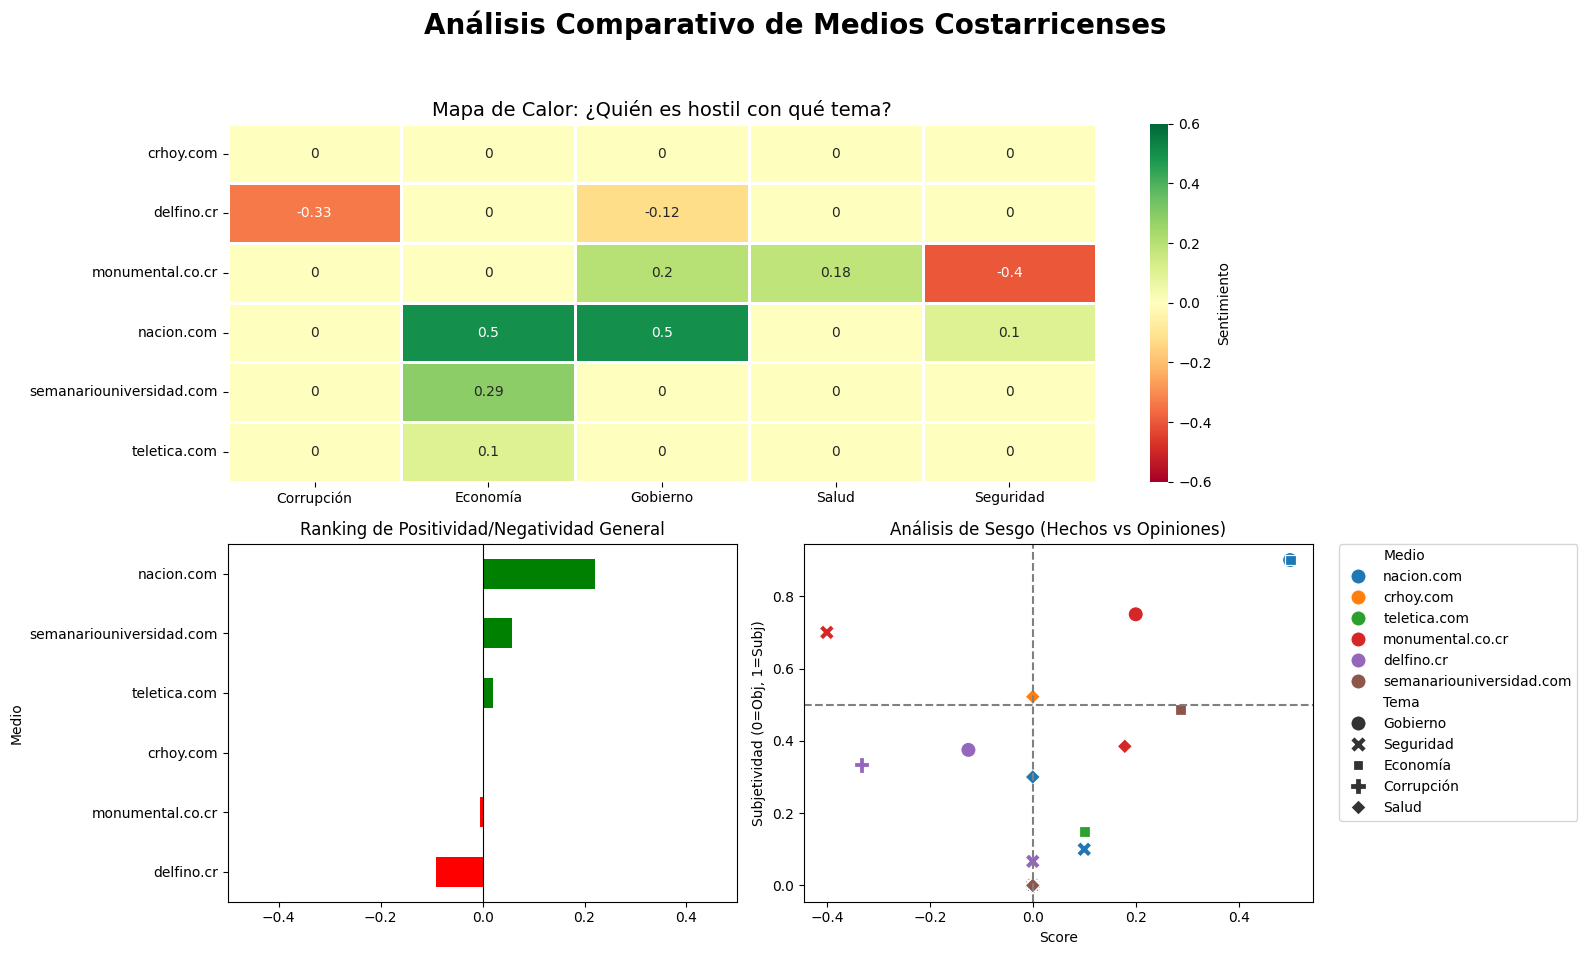


MEDIO                | TEMA            | SCORE  | TITULO
nacion.com           | Gobierno        |  0.50  | Últimas noticias de Costa Rica | La Naci...
crhoy.com            | Gobierno        |  0.00  | CR Hoy - CR Hoy...
teletica.com         | Gobierno        |  0.00  | Laura Fernández da tres nombres de minis...
monumental.co.cr     | Gobierno        |  0.20  | Estados Unidos eliminó aranceles a produ...
delfino.cr           | Gobierno        | -0.12  | Gobierno levanta decreto de emergencia n...
semanariouniversidad | Gobierno        |  0.00  | Debate de presupuesto 2026 se enfocó en ...
nacion.com           | Seguridad       |  0.10  | Ministro de Seguridad pide acción inmedi...
crhoy.com            | Seguridad       |  0.00  | Recope no tiene planes para reforzar seg...
teletica.com         | Seguridad       |  0.00  | Teletica.com | Con vos - Teletica...
monumental.co.cr     | Seguridad       | -0.40  | ¿Ha disminuido la cantidad de sicarios e...
delfino.cr           | Seguridad  

In [ ]:
import feedparser
import trafilatura
import requests
from textblob import TextBlob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd
from deep_translator import GoogleTranslator
from lxml import html
from urllib.parse import quote
import time
import random

# --- CONFIGURACIÓN ---
translator_en = GoogleTranslator(source='auto', target='en')

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept-Language': 'es-419,es;q=0.9'
}
COOKIES = {'CONSENT': 'YES+CB'}

# --- ESTRATEGIA: DIVIDIR PARA VENCER ---
# Seleccionamos los "Gigantes" para garantizar noticias.
# Buscar en sitios pequeños con palabras específicas a veces da 0.
MEDIOS_OBJETIVO = [
    "nacion.com",
    "crhoy.com",
    "teletica.com",
    "monumental.co.cr",
    "delfino.cr",
    "semanariouniversidad.com"
]

def obtener_url_real(google_url):
    """Descifra la URL de Google para llegar a la fuente original."""
    try:
        response = requests.get(google_url, headers=HEADERS, cookies=COOKIES, timeout=4)
        if "google.com" not in response.url:
            return response.url
        tree = html.fromstring(response.content)
        links = tree.xpath('//a/@href')
        for link in links:
            if link.startswith('http') and 'google.com' not in link:
                return link
        return google_url
    except:
        return google_url

def busqueda_quirurgica(keyword, medio):
    """
    Busca EXCLUSIVAMENTE dentro de un sitio web usando el operador 'site:'.
    Ejemplo: site:nacion.com Corrupción
    """
    items = []
    # Consulta de alta precisión
    query = f'site:{medio} {keyword}'
    encoded = quote(query)

    # Usamos el RSS de Google Search general, no el de News, para aceptar el operador site:
    rss_url = f"https://news.google.com/rss/search?q={encoded}&hl=es-419&gl=CR&ceid=CR:es"

    try:
        feed = feedparser.parse(rss_url)

        # Tomamos solo la noticia más reciente de este medio sobre este tema
        # para evitar duplicados y ruido.
        if feed.entries:
            entry = feed.entries[0]

            real_url = obtener_url_real(entry.link)

            items.append({
                "Medio": medio,
                "Tema": keyword,
                "Titulo": entry.title,
                "Link": real_url,
                "Resumen": entry.description if 'description' in entry else ""
            })
    except Exception as e:
        print(f"Error en {medio}: {e}")

    return items

def analizar_lote(items):
    data = []
    total = len(items)
    print(f"\n--- 🧠 Analizando {total} noticias extraídas ---")

    for i, item in enumerate(items):
        print(f"[{i+1}/{total}] {item['Medio']} -> {item['Tema']}", end="\r")

        texto = ""
        # 1. Intentar descargar
        try:
            downloaded = trafilatura.fetch_url(item['Link'])
            if downloaded:
                extracted = trafilatura.extract(downloaded)
                if extracted and len(extracted) > 200:
                    texto = extracted
        except: pass

        # 2. Fallback
        if not texto:
            clean_sum = html.fromstring(item['Resumen']).text_content() if item['Resumen'] else ""
            texto = f"{item['Titulo']}. {clean_sum}"

        # 3. Sentimiento
        try:
            # Traducir (limitado para velocidad)
            txt_en = translator_en.translate(texto[:2000])
            blob = TextBlob(txt_en)

            data.append({
                "Medio": item['Medio'],
                "Tema": item['Tema'],
                "Score": blob.sentiment.polarity,
                "Subjetividad": blob.sentiment.subjectivity,
                "Titulo": item['Titulo']
            })
        except: pass

    return pd.DataFrame(data)

def visualizar_comparativa(df):
    if df.empty:
        print("No hay datos para graficar.")
        return

    # Configuración del Tablero
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2)
    plt.suptitle("Análisis Comparativo de Medios Costarricenses", fontsize=20, fontweight='bold')

    # 1. HEATMAP: MEDIO vs TEMA (La joya del análisis separado)
    ax1 = fig.add_subplot(gs[0, :]) # Toda la fila superior

    # Crear tabla pivote: Filas=Medios, Columnas=Temas, Valores=Sentimiento
    pivot_table = df.pivot_table(index='Medio', columns='Tema', values='Score', aggfunc='mean')

    sns.heatmap(pivot_table, annot=True, cmap="RdYlGn", center=0, vmin=-0.6, vmax=0.6,
                linewidths=1, ax=ax1, cbar_kws={'label': 'Sentimiento'})
    ax1.set_title("Mapa de Calor: ¿Quién es hostil con qué tema?", fontsize=14)
    ax1.set_xlabel("")
    ax1.set_ylabel("")

    # 2. BARRAS: Promedio de Negatividad por Medio
    ax2 = fig.add_subplot(gs[1, 0])
    medios_avg = df.groupby('Medio')['Score'].mean().sort_values()
    colors = ['red' if x < 0 else 'green' for x in medios_avg.values]
    medios_avg.plot(kind='barh', color=colors, ax=ax2)
    ax2.set_title("Ranking de Positividad/Negatividad General")
    ax2.set_xlim(-0.5, 0.5)
    ax2.axvline(0, color='black', linewidth=0.8)

    # 3. DISPERSIÓN: Subjetividad (Editorial vs Noticia)
    ax3 = fig.add_subplot(gs[1, 1])
    sns.scatterplot(data=df, x='Score', y='Subjetividad', hue='Medio', style='Tema', s=120, ax=ax3)
    ax3.axvline(0, color='gray', linestyle='--')
    ax3.axhline(0.5, color='gray', linestyle='--')
    ax3.set_title("Análisis de Sesgo (Hechos vs Opiniones)")
    ax3.set_ylabel("Subjetividad (0=Obj, 1=Subj)")
    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Reporte Escrito
    print("\n" + "="*80)
    print(f"{'MEDIO':<20} | {'TEMA':<15} | {'SCORE':<6} | {'TITULO'}")
    print("="*80)
    for _, row in df.iterrows():
        print(f"{row['Medio'][:20]:<20} | {row['Tema'][:15]:<15} | {row['Score']:>5.2f}  | {row['Titulo'][:40]}...")


def main():
    # KEYWORDS
    keywords = ['Gobierno', 'Seguridad', 'Economía', 'Corrupción', 'Salud']

    print(f"--- 🕵️ ESTRATEGIA: BÚSQUEDA DIRIGIDA POR SITIO ---")
    print(f"Medios: {MEDIOS_OBJETIVO}")
    print(f"Temas: {keywords}\n")

    all_items = []

    # Bucle Doble: Tema x Medio (Garantiza cobertura)
    total_queries = len(keywords) * len(MEDIOS_OBJETIVO)
    count = 0

    print(f">> Ejecutando {total_queries} búsquedas de precisión...")

    for tema in keywords:
        print(f"\n🔍 Buscando sobre '{tema}':")
        for medio in MEDIOS_OBJETIVO:
            res = busqueda_quirurgica(tema, medio)

            if res:
                print(f"   [✔] {medio}: Encontrado")
                all_items.extend(res)
            else:
                print(f"   [ ] {medio}: Sin noticias recientes")

            # Pausa aleatoria para evitar bloqueo (Importante)
            time.sleep(random.uniform(1.0, 2.0))

    if all_items:
        df = analizar_lote(all_items)
        visualizar_comparativa(df)
    else:
        print("\n❌ No se encontró nada. Revisa tu conexión o si Google te está pidiendo captcha.")

if __name__ == "__main__":
    main()